Libraries

In [14]:
import numpy as np
from scipy.spatial import KDTree
from scipy.interpolate import RegularGridInterpolator
import gymnasium as gym
from gymnasium import spaces

PDE and FD reference Parameters


In [15]:
# PDE 
alpha = 0.05

#   FD reference grid   
nx    = 30
T     = 0.6
x_fd  = np.linspace(0.0, 1.0, nx)
dx    = x_fd[1] - x_fd[0]

dt_cfl = 0.45 * dx**2 / alpha
nt     = max(int(np.ceil(T / dt_cfl)) + 1, 10)
t_fd   = np.linspace(0.0, T, nt)
dt     = t_fd[1] - t_fd[0]

Analytical diffusion solution


In [16]:
def u_true(x, t):
    return np.sin(np.pi * x) * np.exp(-alpha * np.pi**2 * t)

FD For diffusion

In [17]:
def build_fd_reference():
    u = np.zeros((nx, nt))
    u[:, 0] = u_true(x_fd, 0.0)

    r_diff = alpha * dt / dx**2

    for it in range(nt - 1):
        un = u[:, it]
        u[1:-1, it+1] = (un[1:-1]
                         + r_diff * (un[2:] - 2*un[1:-1] + un[:-2]))
        u[0,   it+1] = 0.0
        u[-1,  it+1] = 0.0

    interp = RegularGridInterpolator(
        (x_fd, t_fd), u, method='linear',
            bounds_error=False, fill_value=None
    )
    return u, interp

__init__

In [18]:
class VisitedSet:

    def __init__(self, rebuild_every=200):
        self._pts           = []
        self._norm          = []
        self._tree          = None
        self._dirty         = 0
        self._rebuild_every = rebuild_every
        self._idx_set       = set()                    # NEW

    def add(self, x, t, u):
        self._idx_set.add((round(x / dx), round(t / dt)))   # NEW
        self._pts.append((x, t, u))
        self._norm.append((x / dx, t / dt))
        self._dirty += 1
        if self._dirty >= self._rebuild_every:
            self._rebuild()

    def _rebuild(self):
        self._tree  = KDTree(np.array(self._norm))
        self._dirty = 0

    def _ensure(self):
        if self._tree is None:
            self._rebuild()
    def contains(self, x, t):                          # NEW
        return (round(x / dx), round(t / dt)) in self._idx_set
    def find_neighbours(self, x_star, t_star, n):
            if len(self._pts) < n:
                return None

            pts_arr  = np.asarray(self._pts)
            norm_arr = np.asarray(self._norm)

            mask = pts_arr[:, 1] < t_star
            if mask.sum() < n:
                return None

            norm_c = norm_arr[mask]
            pts_c  = pts_arr[mask]

            target = np.array([x_star / dx, t_star / dt])
            d2     = np.sum((norm_c - target) ** 2, axis=1)

            idx = np.argpartition(d2, n - 1)[:n]
            idx = idx[np.argsort(d2[idx])]

            return [tuple(row) for row in pts_c[idx]]

    def __len__(self):
            return len(self._pts)

GFDM Solver


In [19]:
def solve_weights(dx_i, dt_i):
    h = max(np.max(np.abs(dx_i)), 1e-12)

    A = np.array([
        np.ones(len(dx_i)),
        dx_i / h,
        (0.5 * dx_i**2 + alpha * dt_i) / h**2,
    ])
    b = np.array([1.0, 0.0, 0.0])

    cond = np.linalg.cond(A)
    if cond > 1e4:
        return None, 'cond'

    w = np.linalg.lstsq(A, b, rcond=None)[0]

    if np.max(np.abs(w)) > 3.0 / len(dx_i):
        return None, 'weights'
    if np.min(w) < -1.0:
        return None, 'weights'

    return w, 'ok'

In [20]:
ACTIONS = [
    (-1, 0),  # 0: left,  no advance
    ( 0, 0),  # 1: stay,  no advance — always rejected
    (+1, 0),  # 2: right, no advance
    (-1, 1),  # 3: left  + forward
    ( 0, 1),  # 4: straight forward
    (+1, 1),  # 5: right + forward
]

PDEEnvironment

In [21]:
class PDEEnvironment(gym.Env):

    def __init__(self, t_star_steps=2):
        super().__init__()

        self.alpha = alpha

        self.nx   = nx
        self.nt   = nt
        self.x_fd = x_fd
        self.t_fd = t_fd
        self.dx   = dx
        self.dt   = dt
        self.T    = T

        self.x_star = self.x_fd[self.nx // 2]
        self.t_star = t_star_steps * dt

        self.K_max  = 500
        self.lam    = 0.005
        self.Kx     = 1
        self.Kt     = 1
        self.beta   = 100.0

        self.n_neighbours = 5

        self.eps_x = 0.5 * dx
        self.eps_t = 0.5 * dt

        self.N = 10

        mid    = self.nx // 2
        margin = 8
        half_n = self.N // 2
        step   = (mid - margin) / half_n if half_n > 0 else 0

        offsets = [0]
        k = 1
        while len(offsets) < self.N:
            offsets.append(k * step)
            if len(offsets) < self.N:
                offsets.append(-k * step)
            k += 1

        half_span = (self.N // 2) * 2  # grid cells from center to edge
        indices = np.round(mid + np.arange(self.N) * 2 - half_span).astype(int)
        indices = np.clip(indices, 1, self.nx - 2)
        self.walker_init_x = self.x_fd[indices]

        _, self.fd_interp = build_fd_reference()

        self.visited        = None
        self.walker_x       = None
        self.walker_t       = None
        self.walker_u       = None
        self.step_count     = 0
        self.stencil_log    = {}
        self.current_walker = 0

        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(3 * self.N + 2,), dtype=np.float32
        )
        self.action_space = spaces.Discrete(6)


    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self.visited     = VisitedSet()
        self.stencil_log = {}

        for ix in range(self.nx):
            x = self.x_fd[ix]
            self.visited.add(x, 0.0, u_true(x, 0.0))

        for it in range(1, self.nt):
            self.visited.add(0.0, self.t_fd[it], 0.0)
            self.visited.add(1.0, self.t_fd[it], 0.0)

        shuffle_order  = self.np_random.permutation(self.N)
        self.walker_x  = np.array(self.walker_init_x[shuffle_order], dtype=float)
        self.walker_t  = np.zeros(self.N)
        self.walker_u  = np.array([u_true(x, 0.0) for x in self.walker_x])

        self.step_count     = 0
        self.current_walker = 0

        return self._build_obs(), {}


    def _build_obs(self):
        i      = self.current_walker
        others = [j for j in range(self.N) if j != i]
        order  = [i] + others
        return np.array([
            *self.walker_x[order],
            *self.walker_t[order],
            *self.walker_u[order],
            self.x_star,
            self.t_star
        ], dtype=np.float32)


    def _gfdm_solve(self, x_star, t_star):
        nb = self.visited.find_neighbours(x_star, t_star, self.n_neighbours)
        if nb is None:
            return None, False, None, 'no_nb'

        nb   = np.array(nb)
        dx_i = nb[:, 0] - x_star
        dt_i = nb[:, 1] - t_star

        if not (np.min(dx_i) < 0 < np.max(dx_i)):
            return None, False, None, 'geometry'

        w, reason = solve_weights(dx_i, dt_i)
        if w is None:
            return None, False, None, reason

        u_hat = float(w @ nb[:, 2])
        if abs(u_hat) > 1.1:
            return None, False, None, 'bounds_u'
        return u_hat, True, nb[:, :2], 'ok'


    def step(self, action):

        self.step_count += 1
        done   = False
        reward = 0.0

        i              = self.current_walker
        dx_idx, dt_idx = ACTIONS[int(action)]
        dx = dx_idx * self.dx
        dt = dt_idx * self.dt

        info = {'walker': i, 'accepted': False, 'rejected': None, 'reached': False}

        x_new = self.walker_x[i] + dx
        t_new = self.walker_t[i] + dt

        if not (0.0 <= x_new <= 1.0 and 0.0 < t_new <= self.T):
            info['rejected'] = 'bounds'

        elif self.visited.contains(x_new, t_new):
            info['rejected'] = 'collision'

        else:
            u_hat, success, nb_coords, reason = self._gfdm_solve(x_new, t_new)
            if not success:
                info['rejected'] = reason
            else:
                self.visited.add(x_new, t_new, u_hat)
                self.walker_x[i] = x_new
                self.walker_t[i] = t_new
                self.walker_u[i] = u_hat
                self.stencil_log[(round(x_new, 8), round(t_new, 8))] = nb_coords
                info['accepted'] = True

                if (abs(x_new - self.x_star) < self.eps_x and
                    abs(t_new - self.t_star) < self.eps_t):
                    done = True
                    info['reached'] = True

        if done:
            u_pred, _, _, _ = self._gfdm_solve(self.x_star, self.t_star)
            u_ref           = u_true(self.x_star, self.t_star)

            if u_pred is None:
                reward        = -1.0
                info['error'] = None
            else:
                reward = -(self.beta * abs(u_pred - u_ref) + self.lam * self.step_count)
                info['u_pred'] = u_pred
                info['u_ref']  = u_ref
                info['error']  = abs(u_pred - u_ref)
                info['k_term'] = self.step_count

        elif self.step_count >= self.K_max:
            done = True
            reward = -1.0 - self.lam * self.step_count
            info['timeout'] = True

        self.current_walker = (self.current_walker + 1) % self.N

        return self._build_obs(), reward, done, False, info

Steps:          102
Reward:         -0.511028
Reached:        True
Timeout:        False
Total accepted: 54
Total rejected: 48
Rejection reasons:
  collision : 34
  bounds    : 7
  geometry  : 4
  weights   : 3


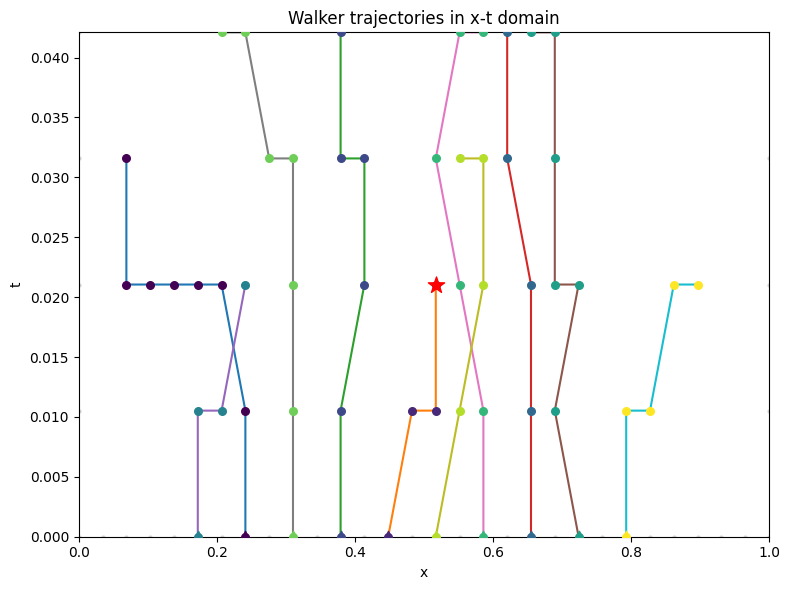

In [22]:
env      = PDEEnvironment()
state, _ = env.reset()

trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}

done           = False
total_accepted = 0
total_rejected = {}

while not done:
    action = env.action_space.sample()                         # MultiDiscrete sample
    state, reward, done, _, info = env.step(action)

    total_accepted += int(info['accepted'])
    if info['rejected']:
        reason = info['rejected']
        total_rejected[reason] = total_rejected.get(reason, 0) + 1

    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))

visited_log = [(x, t) for (x, t, _) in env.visited._pts]

print(f"Steps:          {env.step_count}")
print(f"Reward:         {reward:.6f}")
print(f"Reached:        {info.get('reached', False)}")
print(f"Timeout:        {info.get('timeout', False)}")
print(f"Total accepted: {total_accepted}")
print(f"Total rejected: {sum(total_rejected.values())}")
print("Rejection reasons:")
for reason, count in sorted(total_rejected.items(), key=lambda kv: -kv[1]):
    print(f"  {reason:10s}: {count}")

import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = plt.cm.viridis(np.linspace(0, 1, env.N))
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    ax.plot(xs, ts, '-', linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

In [23]:
def plot_trajectories(model, t_star_steps, save=True, timestep=None,
                      img_dir=".", label=None):
    env = PDEEnvironment(t_star_steps=t_star_steps)
    obs, _ = env.reset()
    trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
    done = False

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, info = env.step(action)
        if info['accepted']:
            i = info['walker']
            trajectories[i].append((env.walker_x[i], env.walker_t[i]))

    visited_log = [(x, t) for (x, t, _) in env.visited._pts]
    fig, ax = plt.subplots(figsize=(8, 6))

    vx = [p[0] for p in visited_log]
    vt = [p[1] for p in visited_log]
    ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    for i, traj in trajectories.items():
        xs = [p[0] for p in traj]
        ts = [p[1] for p in traj]
        ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
        ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
        ax.scatter(xs[0], ts[0], s=80, color=colors[i], marker='^', zorder=4)

    reached = info.get('reached', False)
    outcome = 'reached' if reached else 'timeout'

    # ── Stencil at z* ────────────────────────────────────────────────────────
    if reached:
        _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
        if success and nb_coords is not None:
            for (nx_, nt_) in nb_coords:
                ax.plot([env.x_star, nx_], [env.t_star, nt_],
                        '--', color='red', linewidth=0.8,
                        alpha=0.7, zorder=5)
            ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                       s=40, color='red', zorder=6, alpha=0.7)

    ax.scatter(env.x_star, env.t_star, s=150, color='red', marker='*', zorder=7)
    ax.set_xlabel('x')
    ax.set_ylabel('t')

    title = f't_star={t_star_steps}·dt  |  {outcome}'
    if timestep is not None:
        title += f'  |  step {timestep:,}'
    ax.set_title(title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, env.t_star * 2)
    plt.tight_layout()

    if save:
        if label is not None:
            fname = f'traj_t{t_star_steps}dt_{label}_{outcome}.png'
        elif timestep is not None:
            fname = f'traj_t{t_star_steps}dt_{timestep//1000:05d}k_{outcome}.png'
        else:
            fname = f'traj_t{t_star_steps}dt_{outcome}.png'
        fig.savefig(os.path.join(img_dir, fname), dpi=120)

    plt.close(fig)

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import SubprocVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback

class ReachedRateCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.buf       = []
        self.kterm_buf = []
        self.err_buf   = []

    def _on_step(self) -> bool:
        for info in self.locals['infos']:
            if info.get('reached'):
                self.buf.append(1)
                k = info.get('k_term')
                e = info.get('error')
                if k is not None and e is not None:
                    self.kterm_buf.append(k)
                    self.err_buf.append(e)
            elif info.get('timeout'):
                self.buf.append(0)
        if self.buf:
            self.logger.record('rollout/reached_rate',
                               sum(self.buf[-100:]) / len(self.buf[-100:]))
        if self.kterm_buf:
            self.logger.record('rollout/mean_kterm_on_reach',
                               np.mean(self.kterm_buf[-100:]))
            self.logger.record('rollout/mean_error_on_reach',
                               np.mean(self.err_buf[-100:]))
        return True

In [25]:
%matplotlib inline

In [26]:



class PlotCallback(BaseCallback):
    def __init__(self, t_star_steps, plot_freq=50_000, img_dir=".", verbose=0):
        super().__init__(verbose)
        self.t_star_steps = t_star_steps
        self.plot_freq    = plot_freq
        self.last_plot_at = 0
        self.img_dir      = img_dir

    def _on_step(self) -> bool:
        if self.num_timesteps - self.last_plot_at >= self.plot_freq:
            self.last_plot_at = self.num_timesteps
            plot_trajectories(self.model, self.t_star_steps, save=True,
                              timestep=self.num_timesteps, img_dir=self.img_dir)
        return True


def make_env(t_star_steps):
    def _init():
        return Monitor(PDEEnvironment(t_star_steps=t_star_steps))
    return _init


import os

# ── Run configuration ────────────────────────────────────────────────────────
curriculum   = [2, 3, 4, 5]
lam          = 0.005
beta         = 100
K_max        = 500
n_envs       = 15
n_steps      = 2048 // n_envs

# ── Run directory ────────────────────────────────────────────────────────────
stages_str = "-".join(str(s) for s in curriculum)
run_name   = f"curriculum_t{stages_str}_lam{lam}_beta{beta}_K{K_max}"
run_dir    = os.path.join("runs2", run_name)
img_dir    = os.path.join(run_dir, "images")
ckpt_dir   = os.path.join(run_dir, "checkpoints")

os.makedirs(img_dir,  exist_ok=True)
os.makedirs(ckpt_dir, exist_ok=True)

print(f"Run directory: {run_dir}")

 # ── Model ────────────────────────────────────────────────────────────────────
vec_env = SubprocVecEnv([make_env(curriculum[0]) for _ in range(n_envs)])
model = PPO(
    "MlpPolicy",
    vec_env,
    verbose=1,
    gamma=1.0,
    ent_coef=0.01,
    device="cpu",
    n_steps=n_steps,
    batch_size=60,
    tensorboard_log=os.path.join(run_dir, "logs"),
)

# ── Curriculum ───────────────────────────────────────────────────────────────
timesteps_per_stage = {t: t *1_000_000 for t in curriculum}

for t_star_steps in curriculum:
    print(f"\n{'='*50}")
    print(f"Stage: t_star = {t_star_steps}·dt = {t_star_steps * dt:.4f}  |  budget: {t_star_steps * 1_000_000 // 1000}k steps")
    print(f"{'='*50}")

    vec_env = SubprocVecEnv([make_env(t_star_steps) for _ in range(n_envs)])
    model.set_env(vec_env)

    model.learn(
        total_timesteps=timesteps_per_stage[t_star_steps],
        reset_num_timesteps=False,
        tb_log_name=run_name,
        log_interval=10,
        callback=[
            ReachedRateCallback(),
            PlotCallback(t_star_steps, plot_freq=20_000, img_dir=img_dir),
            CheckpointCallback(
                save_freq=20_000,
                save_path=os.path.join(ckpt_dir, f"tstar{t_star_steps}"),
                name_prefix=f"tstar{t_star_steps}"
            ),
        ],
    )

    model.save(os.path.join(ckpt_dir, f"tstar{t_star_steps}_final"))
    plot_trajectories(model, t_star_steps, save=True,
                      timestep=None, img_dir=img_dir, label="final")

Run directory: runs2\curriculum_t2-3-4-5_lam0.005_beta100_K500
Using cpu device

Stage: t_star = 2·dt = 0.0211  |  budget: 2000k steps
Logging to runs2\curriculum_t2-3-4-5_lam0.005_beta100_K500\logs\curriculum_t2-3-4-5_lam0.005_beta100_K500_0
-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 179         |
|    ep_rew_mean          | -1.19       |
|    mean_error_on_reach  | 1.52e-05    |
|    mean_kterm_on_reach  | 48.1        |
|    reached_rate         | 0.71        |
| time/                   |             |
|    fps                  | 2978        |
|    iterations           | 10          |
|    time_elapsed         | 6           |
|    total_timesteps      | 20400       |
| train/                  |             |
|    approx_kl            | 0.008164171 |
|    clip_fraction        | 0.0656      |
|    clip_range           | 0.2         |
|    entropy_loss         | -1.74       |
|    explained_variance   | 0.835       |
|

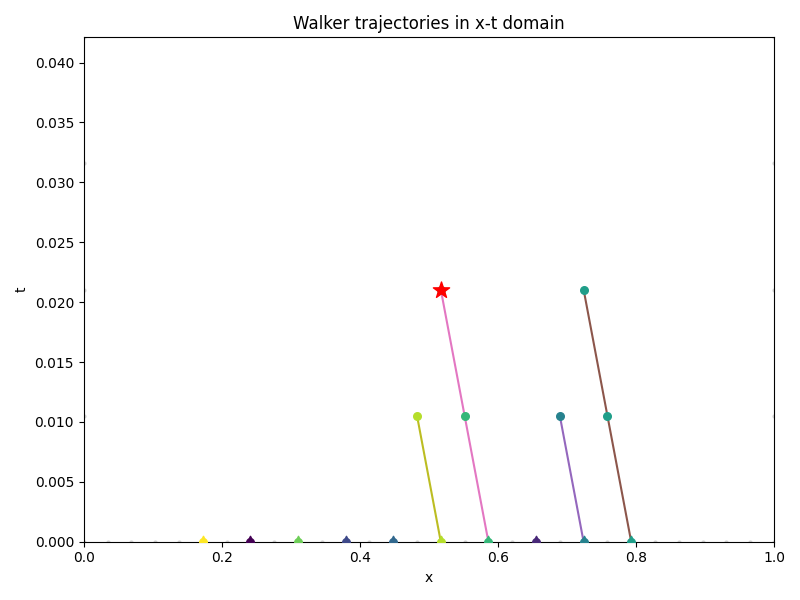

In [43]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
obs, _ = env.reset()
trajectories = {i: [(env.walker_x[i], env.walker_t[i])] for i in range(env.N)}
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, info = env.step(action)
    if info['accepted']:
        i = info['walker']
        trajectories[i].append((env.walker_x[i], env.walker_t[i]))
        
visited_log = [(x, t) for (x, t, _) in env.visited._pts]
fig, ax = plt.subplots(figsize=(8, 6))

vx = [p[0] for p in visited_log]
vt = [p[1] for p in visited_log]
ax.scatter(vx, vt, s=4, color='lightgray', zorder=1, label='Visited')

colors = cm.tab10.colors
for i, traj in trajectories.items():
    xs = [p[0] for p in traj]
    ts = [p[1] for p in traj]
    colors = plt.cm.viridis(np.linspace(0, 1, env.N))
    ax.plot(xs, ts, '-',  linewidth=1.5, zorder=2)
    ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
    ax.scatter(xs[0], ts[0], s=80, color=colors[i],
               marker='^', zorder=4, label=f'Walker {i}')

ax.scatter(env.x_star, env.t_star, s=150, color='red',
           marker='*', zorder=5, label='z*')

ax.set_xlabel('x')
ax.set_ylabel('t')
ax.set_title('Walker trajectories in x-t domain')
ax.set_xlim(0, 1)
ax.set_ylim(0, env.t_star * 2)
plt.tight_layout()
plt.show()

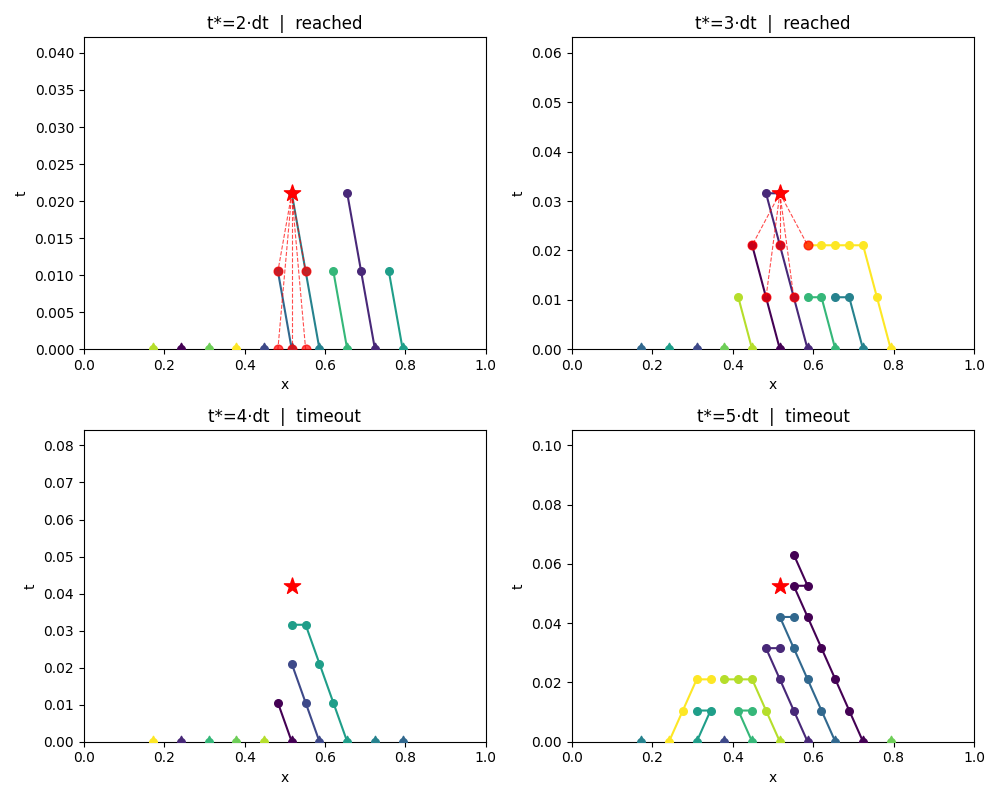

Saved to runs2\curriculum_t2-3-4-5_lam0.005_beta100_K500\images\all_stages_final.png


In [ ]:
def plot_all_stages(model, curriculum, img_dir="."):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.flatten()

    for ax, t_star_steps in zip(axes, curriculum):
        env = PDEEnvironment(t_star_steps=t_star_steps)
        obs, _ = env.reset()
        trajectories = {i: [(env.walker_x[i], env.walker_t[i])]
                        for i in range(env.N)}
        done = False

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, _, info = env.step(action)
            if info['accepted']:
                i = info['walker']
                trajectories[i].append((env.walker_x[i], env.walker_t[i]))

        # filter out IC/BC seeded points — only show walker-visited points
        walker_visited = [(x, t) for (x, t, _) in env.visited._pts
                          if t > 0.0 and 0.0 < x < 1.0]
        if walker_visited:
            vx = [p[0] for p in walker_visited]
            vt = [p[1] for p in walker_visited]
            ax.scatter(vx, vt, s=4, color='lightgray', zorder=1)

        colors = plt.cm.viridis(np.linspace(0, 1, env.N))
        for i, traj in trajectories.items():
            xs = [p[0] for p in traj]
            ts = [p[1] for p in traj]
            ax.plot(xs, ts, '-', linewidth=1.5, color=colors[i], zorder=2)
            ax.scatter(xs, ts, s=30, color=colors[i], zorder=3)
            ax.scatter(xs[0], ts[0], s=80, color=colors[i],
                       marker='^', zorder=4)

        reached = info.get('reached', False)
        outcome = 'reached' if reached else 'timeout'

        if reached:
            _, success, nb_coords, _ = env._gfdm_solve(env.x_star, env.t_star)
            if success and nb_coords is not None:
                for (nx_, nt_) in nb_coords:
                    ax.plot([env.x_star, nx_], [env.t_star, nt_],
                            '--', color='red', linewidth=0.8,
                            alpha=0.7, zorder=5)
                ax.scatter(nb_coords[:, 0], nb_coords[:, 1],
                           s=40, color='red', zorder=6, alpha=0.7)

        ax.scatter(env.x_star, env.t_star,
                   s=150, color='red', marker='*', zorder=7)
        ax.set_xlabel('x')
        ax.set_ylabel('t')
        ax.set_title(f't*={t_star_steps}·dt  |  {outcome}')
        ax.set_xlim(0, 1)
        ax.set_ylim(0, env.t_star * 2)

    plt.tight_layout()
    fname = os.path.join(img_dir, 'all_stages_final.png')
    fig.savefig(fname, dpi=120)
    plt.show()
    print(f"Saved to {fname}")
                    
plot_all_stages(model, curriculum, img_dir=img_dir)